In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_excel('TradeData.xlsx')
df

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20200101,2020,52,2020,8,ALB,Albania,M,...,0.0,False,0,False,5.410943e+09,0.000000e+00,5.410943e+09,0,False,True
1,C,A,20200101,2020,52,2020,8,ALB,Albania,X,...,0.0,True,0,False,0.000000e+00,2.415632e+09,2.415632e+09,4,False,True
2,C,A,20200101,2020,52,2020,20,AND,Andorra,M,...,0.0,True,0,False,1.494812e+09,NaN,1.494812e+09,4,False,True
3,C,A,20200101,2020,52,2020,20,AND,Andorra,X,...,0.0,True,0,False,NaN,1.667811e+08,1.667811e+08,4,False,True
4,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,True,0,False,9.337926e+09,NaN,9.337926e+09,4,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1593,C,A,20240101,2024,52,2024,860,UZB,Uzbekistan,X,...,0.0,True,0,False,NaN,1.973545e+10,1.973545e+10,4,False,True
1594,C,A,20240101,2024,52,2024,882,WSM,Samoa,M,...,NaN,False,0,False,4.902038e+08,NaN,4.902038e+08,0,False,True
1595,C,A,20240101,2024,52,2024,882,WSM,Samoa,X,...,0.0,True,0,False,NaN,4.191940e+07,4.191940e+07,4,False,True
1596,C,A,20240101,2024,52,2024,894,ZMB,Zambia,M,...,NaN,False,0,False,1.126801e+10,NaN,1.126801e+10,0,False,True


#**Column Description**
**typeCode**: The type of data (e.g., 'C' for Commodities).

**freqCode**: The frequency of the report (e.g., 'A' for Annual).

**refPeriodId / refYear / refMonth / period**: Various ways of representing the time period. For annual data, the year is the primary reference.

**reporterCode**: A unique numeric ID for the reporting country.

**reporterISO**: The 3-letter ISO country code (e.g., ALB for Albania).

**reporterDesc**: The full name of the reporting country.

**flowCode**: A short code for the direction of trade.

**flowDesc**: Description of the trade direction (e.g., Import, Export, Re-import, Re-export).

**partnerCode / partnerISO / partnerDesc**: Information about the primary trading partner. If the value is World, it represents the total trade for that reporter across all partners.

**partner2Code / partner2ISO / partner2Desc**: Information about a secondary partner (often used for more complex trade tracking like "country of consignment").

**classificationCode**: The system used to classify the goods (e.g., H5 refers to the Harmonized System 2017).

**cmdCode**: The commodity code (e.g., TOTAL for all goods, or specific digits like 01 for live animals).

**cmdDesc**: A description of the commodity (e.g., "All Commodities").

**aggrLevel**: The level of detail for the commodity (0 is the highest aggregate, while higher numbers are more specific).

**isLeaf**: A boolean (True/False) indicating if the commodity is at the most detailed level of the classification.

**qtyUnitCode / qtyUnitAbbr / qty**: The unit of measurement (e.g., kilograms, liters) and the actual quantity.

**netWgt / grossWgt**: The net weight (excluding packaging) and gross weight (including packaging) of the goods.

**isQtyEstimated / isNetWgtEstimated / etc.**: Boolean flags indicating whether the recorded quantity or weight was reported directly or estimated by the UN.

**cifvalue**: "Cost, Insurance, and Freight" — the value of goods including the costs of shipping and insurance (typically used for imports).

**fobvalue**: "Free on Board" — the value of goods at the point of export, excluding shipping and insurance (typically used for exports).

**primaryValue**: The main value used for statistical analysis, usually derived from either the CIF or FOB value.

**customsCode / customsDesc**: Information regarding the customs procedure used.

**motCode / motDesc**: The Mode of Transport (e.g., Sea, Air, Road).

**mosCode**: The Mode of Supply (usually relevant for services).

**isReported**: Indicates if the data was officially reported by the country.

**isAggregate**: Indicates if the row represents a sum/total of other sub-categories.

#**Basic Info**

In [4]:
df.shape

(1598, 47)

In [5]:
df.head()

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20200101,2020,52,2020,8,ALB,Albania,M,...,0.0,False,0,False,5.410943e+09,0.000000e+00,5.410943e+09,0,False,True
1,C,A,20200101,2020,52,2020,8,ALB,Albania,X,...,0.0,True,0,False,0.000000e+00,2.415632e+09,2.415632e+09,4,False,True
2,C,A,20200101,2020,52,2020,20,AND,Andorra,M,...,0.0,True,0,False,1.494812e+09,NaN,1.494812e+09,4,False,True
3,C,A,20200101,2020,52,2020,20,AND,Andorra,X,...,0.0,True,0,False,NaN,1.667811e+08,1.667811e+08,4,False,True
4,C,A,20200101,2020,52,2020,24,AGO,Angola,M,...,0.0,True,0,False,9.337926e+09,NaN,9.337926e+09,4,False,True


In [6]:
df.tail()

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
1593,C,A,20240101,2024,52,2024,860,UZB,Uzbekistan,X,...,0.0,True,0,False,NaN,1.973545e+10,1.973545e+10,4,False,True
1594,C,A,20240101,2024,52,2024,882,WSM,Samoa,M,...,NaN,False,0,False,4.902038e+08,NaN,4.902038e+08,0,False,True
1595,C,A,20240101,2024,52,2024,882,WSM,Samoa,X,...,0.0,True,0,False,NaN,4.191940e+07,4.191940e+07,4,False,True
1596,C,A,20240101,2024,52,2024,894,ZMB,Zambia,M,...,NaN,False,0,False,1.126801e+10,NaN,1.126801e+10,0,False,True
1597,C,A,20240101,2024,52,2024,894,ZMB,Zambia,X,...,NaN,False,0,False,NaN,1.127583e+10,1.127583e+10,0,False,True


In [7]:
df.columns

Index(['typeCode', 'freqCode', 'refPeriodId', 'refYear', 'refMonth', 'period',
       'reporterCode', 'reporterISO', 'reporterDesc', 'flowCode', 'flowDesc',
       'partnerCode', 'partnerISO', 'partnerDesc', 'partner2Code',
       'partner2ISO', 'partner2Desc', 'classificationCode',
       'classificationSearchCode', 'isOriginalClassification', 'cmdCode',
       'cmdDesc', 'aggrLevel', 'isLeaf', 'customsCode', 'customsDesc',
       'mosCode', 'motCode', 'motDesc', 'qtyUnitCode', 'qtyUnitAbbr', 'qty',
       'isQtyEstimated', 'altQtyUnitCode', 'altQtyUnitAbbr', 'altQty',
       'isAltQtyEstimated', 'netWgt', 'isNetWgtEstimated', 'grossWgt',
       'isGrossWgtEstimated', 'cifvalue', 'fobvalue', 'primaryValue',
       'legacyEstimationFlag', 'isReported', 'isAggregate'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1598 entries, 0 to 1597
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   typeCode                  1598 non-null   object 
 1   freqCode                  1598 non-null   object 
 2   refPeriodId               1598 non-null   int64  
 3   refYear                   1598 non-null   int64  
 4   refMonth                  1598 non-null   int64  
 5   period                    1598 non-null   int64  
 6   reporterCode              1598 non-null   int64  
 7   reporterISO               1598 non-null   object 
 8   reporterDesc              1598 non-null   object 
 9   flowCode                  1598 non-null   object 
 10  flowDesc                  1598 non-null   object 
 11  partnerCode               1598 non-null   int64  
 12  partnerISO                1598 non-null   object 
 13  partnerDesc               1598 non-null   object 
 14  partner2

In [9]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
1593,False
1594,False
1595,False
1596,False


In [10]:
num_data=df.select_dtypes(include=["float64","int64"])
print("numerical colums",num_data.columns)

numerical colums Index(['refPeriodId', 'refYear', 'refMonth', 'period', 'reporterCode',
       'partnerCode', 'partner2Code', 'aggrLevel', 'mosCode', 'motCode',
       'qtyUnitCode', 'qtyUnitAbbr', 'qty', 'altQtyUnitCode', 'altQtyUnitAbbr',
       'altQty', 'netWgt', 'grossWgt', 'cifvalue', 'fobvalue', 'primaryValue',
       'legacyEstimationFlag'],
      dtype='object')


In [11]:
cat_data=df.select_dtypes(include=["O"])
print("categorical colums",cat_data.columns)

categorical colums Index(['typeCode', 'freqCode', 'reporterISO', 'reporterDesc', 'flowCode',
       'flowDesc', 'partnerISO', 'partnerDesc', 'partner2ISO', 'partner2Desc',
       'classificationCode', 'classificationSearchCode', 'cmdCode', 'cmdDesc',
       'customsCode', 'customsDesc', 'motDesc'],
      dtype='object')


In [12]:
for i in cat_data:
    print(i,df[i].unique())
    print(df[i].value_counts())
    print("**********************")

typeCode ['C']
typeCode
C    1598
Name: count, dtype: int64
**********************
freqCode ['A']
freqCode
A    1598
Name: count, dtype: int64
**********************
reporterISO ['ALB' 'AND' 'AGO' 'ATG' 'AZE' 'ARG' 'AUS' 'AUT' 'BHS' 'BHR' 'ARM' 'BRB'
 'BEL' 'BMU' 'BTN' 'BOL' 'BIH' 'BWA' 'BRA' 'BLZ' 'BRN' 'BGR' 'MMR' 'BDI'
 'BLR' 'KHM' 'CMR' 'CAN' 'CPV' 'CYM' 'CAF' 'LKA' 'CHL' 'CHN' 'COL' 'COM'
 'COG' 'COD' 'CRI' 'HRV' 'CUB' 'CYP' 'CZE' 'BEN' 'DNK' 'DMA' 'DOM' 'ECU'
 'SLV' 'ETH' 'EST' 'FJI' 'FIN' 'FRA' 'PYF' 'GAB' 'GEO' 'GMB' 'PSE' 'DEU'
 'KIR' 'GRC' 'GRD' 'GTM' 'GUY' 'HND' 'HKG' 'HUN' 'ISL' 'IDN' 'IRN' 'IRL'
 'ISR' 'ITA' 'CIV' 'JAM' 'JPN' 'KAZ' 'JOR' 'KEN' 'KOR' 'KWT' 'KGZ' 'LAO'
 'LBN' 'LSO' 'LVA' 'LBR' 'LTU' 'LUX' 'MAC' 'MDG' 'MWI' 'MYS' 'MDV' 'MLI'
 'MLT' 'MRT' 'MUS' 'MEX' 'S19' 'MNG' 'MDA' 'MNE' 'MSR' 'MAR' 'MOZ' 'OMN'
 'NAM' 'NPL' 'NLD' 'CUW' 'ABW' 'NZL' 'NIC' 'NER' 'NGA' 'NOR' 'PAK' 'PAN'
 'PNG' 'PRY' 'PER' 'PHL' 'POL' 'PRT' 'TLS' 'QAT' 'ROU' 'RUS' 'RWA' 'LCA'
 'VCT' 'STP' 'SAU' 

#**Statistics**

**primaryValue** is our target column for the trade volume analysis. For the Crude Oil dataset, this column represents the total monetary value of the trade, which is the standard metric used to measure economic influence and market shifts.

In [13]:
brics_countries = ['Brazil', 'Russian Federation', 'India', 'China', 'South Africa',
                   'Egypt', 'Ethiopia', 'Iran', 'Saudi Arabia', 'United Arab Emirates']

In [14]:
df['Category'] = df['reporterDesc'].apply(lambda x: 'BRICS+' if x in brics_countries else 'Other')

In [15]:
print("---  Basic Statistical Summary ---")
summary_stats = df['primaryValue'].describe()
print(summary_stats)

--- 1. Basic Statistical Summary ---
count    1.598000e+03
mean     1.353802e+11
std      3.586006e+11
min      5.713782e+06
25%      3.726023e+09
50%      1.479179e+10
75%      9.121750e+10
max      3.593601e+12
Name: primaryValue, dtype: float64


##**Key Insights**

**1.** Mean is **💲135 Billion** and the median is **💲14.8 Billion**.  

Because the mean is nearly 10 times higher than the median, it tells us the data is "heavily skewed." Countries like China, the USA, and Russia are trading in the Trillions, while the majority of countries are trading in much smaller amounts.

**2.** The 75% point is **💲91 billion** and the max value is **💲3.5 Trillion**.

Even at the 75th percentile, the value is only 91 Billion dollars. The jump to 3.5 Trillion dollars for the maximum value shows that the top 1% or 5% of trading nations control the vast majority of the global oil market's wealth.

**3.** The standard deviation is **💲358 Billion** which is much larger than the average **💲135 Billion**.

This high "Standard Deviation" means the trade values are spread very far apart. This isn't a "stable" market where everyone trades roughly the same amount.

In [16]:
print("--- Total Trade Value by Year ---")
yearly_totals = df.groupby('refYear')['primaryValue'].sum()
print(yearly_totals)
print("\n")

--- 2. Total Trade Value by Year ---
refYear
2020    3.454796e+13
2021    4.365968e+13
2022    4.819251e+13
2023    4.575601e+13
2024    4.418136e+13
Name: primaryValue, dtype: float64




##**Key Insights**
**1.** You will see a significant spike in 2022 is **$48.2 Trillion**. This highlights how geopolitical tensions (like the Russia-Ukraine conflict) immediately translate into higher trade values due to global price surges.

**2.** Although value dipped slightly in 2024 is **$44.2 Trillion** compared to the 2022 peak, it remains much higher than 2020 which is **34.5 Trillion**. This shows that the world has settled into higher energy costs and higher trade values.

In [17]:
print("---  Total Value by Trade Flow (Import vs Export) ---")
flow_totals = df.groupby('flowDesc')['primaryValue'].sum()
print(flow_totals)
print("\n")

--- 3. Total Value by Trade Flow (Import vs Export) ---
flowDesc
Export    1.068569e+14
Import    1.094807e+14
Name: primaryValue, dtype: float64




#**Key Insights**

**1.** Imports are **💲109 Trillion** and Exports are **💲106 Trillion** are nearly equal is a sign of reliable reporting. It confirms that the transactions recorded by sellers are being accurately captured by buyers globally.

**2.** Imports are roughly **2-3%** higher than exports. This small gap represents the "invisible" costs of trade, such as shipping, insurance are CIF, which are added to the value of goods when they arrive at their destination.

In [19]:
print("--- Top 10 Countries by Total Trade Value ---")
top_10_countries = df.groupby('reporterDesc')['primaryValue'].sum().sort_values(ascending=False).head(10)
print(top_10_countries)
print("\n")

--- Top 10 Countries by Total Trade Value ---
reporterDesc
China                   2.906189e+13
USA                     2.456437e+13
Germany                 1.513353e+13
Japan                   7.371058e+12
France                  6.680165e+12
Netherlands             6.544662e+12
China, Hong Kong SAR    6.354480e+12
Rep. of Korea           6.243576e+12
United Kingdom          6.176174e+12
Italy                   6.035387e+12
Name: primaryValue, dtype: float64




#**Key Insights**
**1.** The data shows that a shift in the first 3 nations can dictate the price and supply for the other nations.

**2.** China has **💲29.06 Trillion** and the USA **💲24.56 Trillion** togather account for the **25 %** of the total global trade value.

In [20]:
print("---  BRICS+ vs Other Nations (Total Value) ---")
brics_vs_others = df.groupby('Category')['primaryValue'].sum()
print(brics_vs_others)

--- 5. BRICS+ vs Other Nations (Total Value) ---
Category
BRICS+    4.599599e+13
Other     1.703415e+14
Name: primaryValue, dtype: float64


#**Key Insights**

**1.** While "Other" nations still hold the majority, the BRICS+ group controls **💲46 Trillion**, which is approximately **21.3% **which is **more than one-fifth** of the total global trade value in your dataset.

**2.** The **💲170 Trillion** held by "Other" nations mostly Western-aligned economies using the USD is still nearly **4 times larger** than the BRICS+ share.

In [21]:
total_2020 = yearly_totals[2020]
total_2024 = yearly_totals[2024]
growth_percent = ((total_2024 - total_2020) / total_2020) * 100

print("\n---  Overall Market Growth ---")
print(f"Total growth in trade value from 2020 to 2024: {growth_percent:.2f}%")


--- 6. Overall Market Growth ---
Total growth in trade value from 2020 to 2024: 27.88%


#**Key Insights**

**1.** An overall growth of nearly **28%** since 2020 proves that the monetary reliance on Crude Oil is actually increasing, not decreasing.

**2.** The growth in trade value suggests that oil acts as a natural hedge. As the US Dollar fluctuates, the value of oil trade has risen

#**Data Visualization**


In [22]:
brics_iso = ['BRA', 'RUS', 'IND', 'CHN', 'ZAF', 'SAU', 'ARE', 'EGY', 'ETH', 'IRN']
df['Category'] = df['reporterISO'].apply(lambda x: 'BRICS+' if x in brics_iso else 'Other')

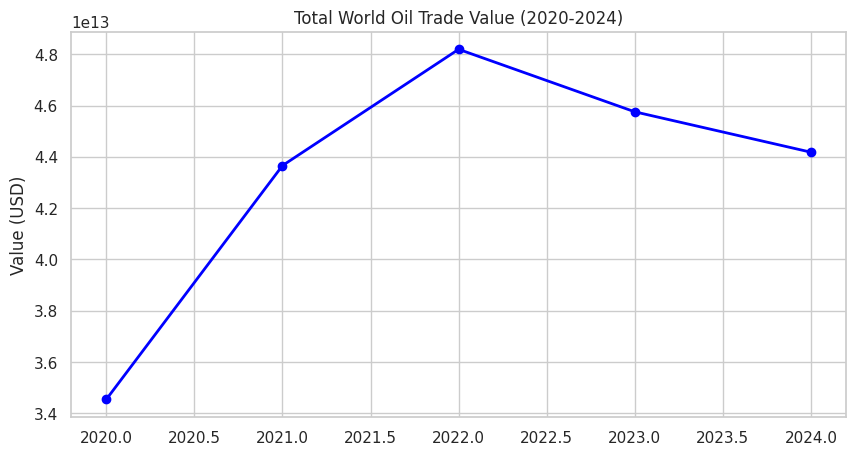

In [23]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
yearly_totals = df.groupby('refYear')['primaryValue'].sum()
plt.plot(yearly_totals.index, yearly_totals.values, marker='o', color='blue', linewidth=2)
plt.title('Total World Oil Trade Value (2020-2024)')
plt.ylabel('Value (USD)')
plt.show()

#**Key Insights**

**1.** The line shows a sharp **upward slope** until 2022. This visualizes the "Energy Shock" where global tensions made oil much more expensive.

**2** The slight dip in 2023–2024 suggests the market is stabilizing, though it remains at a significantly higher value floor than in 2020.

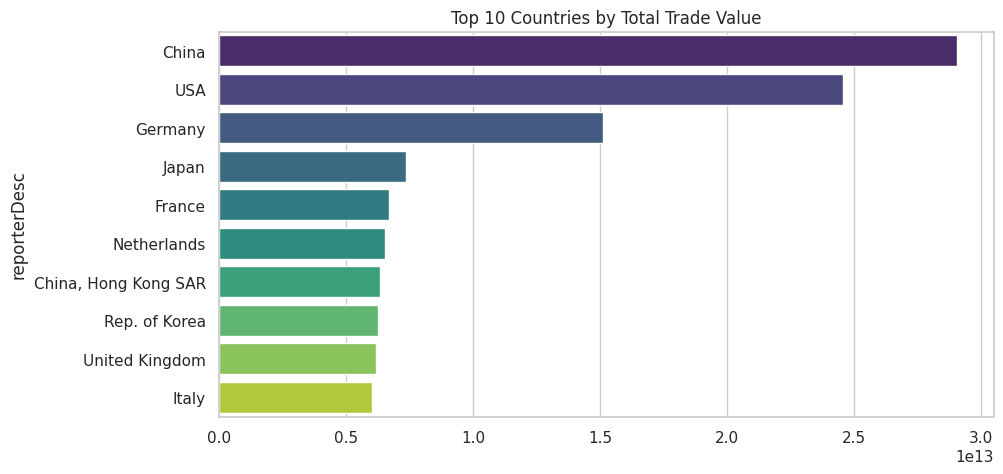

In [24]:
plt.figure(figsize=(10, 5))
top_10 = df.groupby('reporterDesc')['primaryValue'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_10.values, y=top_10.index, palette='viridis')
plt.title('Top 10 Countries by Total Trade Value')
plt.show()

#**Key Insights**

**1.** The chart is dominated by China and the USA. These bars are **much longer** than the others, showing that these two nations act as the leaders of the global oil economy.

**2.** Several European nations such as **Germany, France, Netherlands** appear in the top 10, highlighting that while BRICS+ are major producers, the Western Block still controls the largest share of recorded trade value.

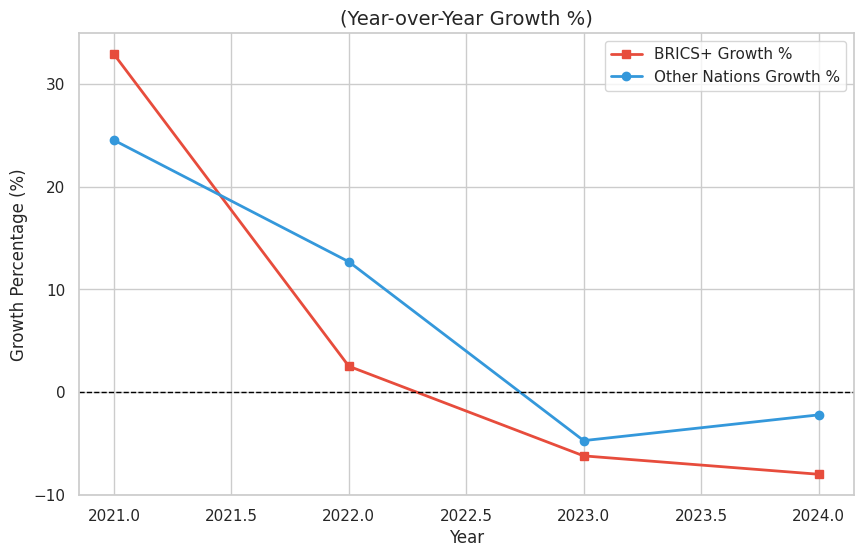

In [29]:
growth_df = df.groupby(['refYear', 'Category'])['primaryValue'].sum().unstack()
growth_pct = growth_df.pct_change() * 100
plt.figure(figsize=(10, 6))
plt.plot(growth_pct.index, growth_pct['BRICS+'], marker='s', label='BRICS+ Growth %', color='#e74c3c', linewidth=2)
plt.plot(growth_pct.index, growth_pct['Other'], marker='o', label='Other Nations Growth %', color='#3498db', linewidth=2)

plt.title('(Year-over-Year Growth %)', fontsize=14)
plt.ylabel('Growth Percentage (%)')
plt.xlabel('Year')
plt.axhline(0, color='black', linestyle='--', linewidth=1) # Zero line
plt.legend()
plt.show()

#**Key Insights**

**1.** In 2021, BRICS+ trade value grew by approx **33%**, significantly outperforming "Other" nations **25%**. This shows that the BRICS alliance recovered from the initial COVID-19 shock much faster than the rest of the global market.

**2.** In 2023 and 2024, both groups saw **negative growth** (a decline in value). However, the BRICS+ decline was sharper than the Others.

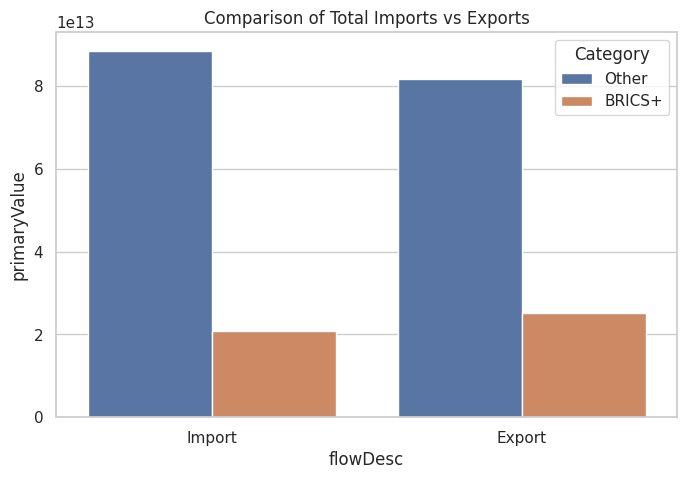

In [30]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='flowDesc', y='primaryValue', hue='Category', estimator=sum, ci=None)
plt.title('Comparison of Total Imports vs Exports')
plt.show()

**Key Insights**

**1.** For the BRICS+ group, Exports **💲25 Trillion** are higher than Imports **💲21 Trillion**. This confirms that BRICS+ is a "Net Seller" of commodities to the rest of the world.

**2.** For the other countries the Imports are around **💲89 Trillion** and the Exports are around **💲81 Trillion**, which depicts that the other countries have imported a large amount than the export value.